<a href="https://colab.research.google.com/github/ilijaaaa/siap/blob/main/siap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Predikcija religija država - SIAP projekat**
Ilija Vitošević E2 86/2025 i
Nikola Magdić E2 52/2025

# **O projektu:**
Razvijamo sistem za predikciju religije država na osnovu csv skupa
podataka uz evaluaciju različitih klasifikacionih algoritama i analizu značajnih pojedinih atributa. Analizom simbola i boja na zastavama, u kombinaciji sa geopolitičkim podacima, može se ustanoviti u
kojoj meri vizuelni identitet države opisuje njen kulturni i religijski profil.

Biblioteke koje se koriste u delu eksplorativne analize:

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

## **Eksplorativna analiza**
Ova analiza podeljena je na tri dela. U prvom delu se bavimo prostom analizom distribucijom odrđenih atributa koje smo procenili kao najbitnije za naš zadatak. U drugom delu smo konkretno upoređivali atribut religion sa ostalim atributima koje smo smatrali najkorisnijim u istraživanju. U trećem delu prisutna je matrica korelacije koja prikazuje međusobni odnos numeričkih atrbuta.

**Korišćene biblioteke u delu eksplorativne analize:**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

**Učitavanje skupa podataka i prikaz osnovnih detalja o njemu:**

(Za učitavanje je potrebno da fajl imate lokalno kod sebe i da ga dodate u dijalog prozoru nakon pokretanja izvršavanja.)

In [ ]:
uploaded = files.upload()

columns = [
    "name","landmass","zone","area","population","language","religion","bars","stripes","colours",
    "red","green","blue","gold","white","black","orange","mainhue","circles","crosses",
    "saltires","quarters","sunstars","crescent","triangle","icon","animate","text","topleft","botright"
]

df = pd.read_csv("flag.data", header=None, names=columns)

print('Skup podataka:')
print(df)

print('\nDimenzije df-a:')
print(df.shape)

print('\nProvera da li postoje nedostajuce vrednosti:')
print(df.isna().sum())

Saving flag.data to flag (1).data
Skup podataka:
               name  landmass  zone  area  population  language  religion  \
0       Afghanistan         5     1   648          16        10         2   
1           Albania         3     1    29           3         6         6   
2           Algeria         4     1  2388          20         8         2   
3    American-Samoa         6     3     0           0         1         1   
4           Andorra         3     1     0           0         6         0   
..              ...       ...   ...   ...         ...       ...       ...   
189   Western-Samoa         6     3     3           0         1         1   
190      Yugoslavia         3     1   256          22         6         6   
191           Zaire         4     2   905          28        10         5   
192          Zambia         4     2   753           6        10         5   
193        Zimbabwe         4     2   391           8        10         5   

     bars  stripes  colour

Podaci su uspešno učitani. Skup ima 194 reda i 30 kolona. Nema nedostajućih vrednosti.

Na početku ove ćelije koda imamo potrebu da definišemo columns kao niz oznaka kolona, jer u skupu podataka ne postoji heder koji bi te kolone opisao.

**Sledi prvi deo analize:**

1. Prati se distribucija mainhue (dominantne boje) po broju zemalja.

/tmp/ipython-input-166/783593061.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='mainhue', palette=colors.keys(), edgecolor='black', linewidth=2)


([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'green'),
  Text(1, 0, 'red'),
  Text(2, 0, 'blue'),
  Text(3, 0, 'gold'),
  Text(4, 0, 'white'),
  Text(5, 0, 'orange'),
  Text(6, 0, 'black'),
  Text(7, 0, 'brown')])

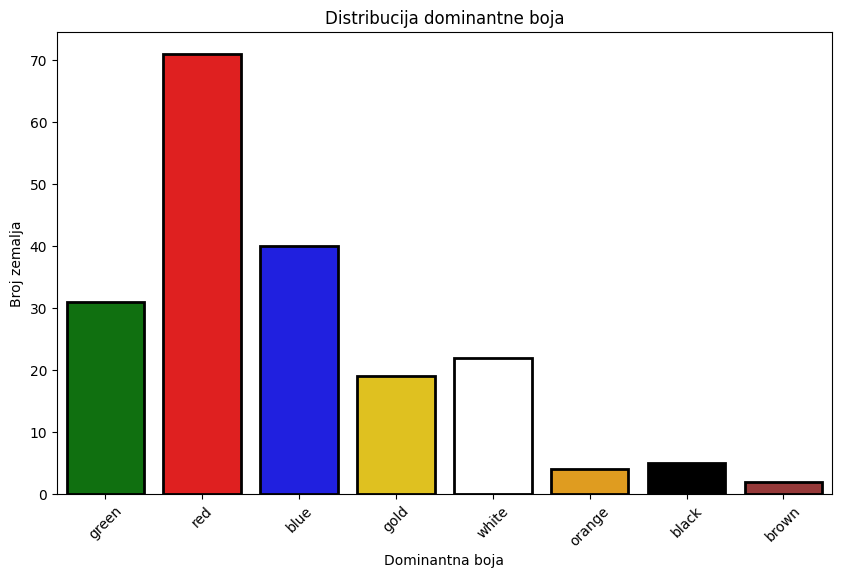

In [ ]:
colors = {'green': 'green', 'red' : 'red', 'blue': 'blue', 'gold': 'gold',
          'white': 'white', 'orange': 'orange', 'black': 'black', 'brown': 'brown'}
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='mainhue', palette=colors.keys(), edgecolor='black', linewidth=2)
plt.title('Distribucija dominantne boja')
plt.xlabel('Dominantna boja')
plt.ylabel('Broj zemalja')
plt.xticks(rotation=45)

Primetno je da crvena boja ima najdominantnije prisustvo na svetskim zastavama, dok je najmanje prisutna braon boja.

2. Prati se distribucija broja boja (colours) na zastavama po broju zemalja.

/tmp/ipython-input-166/1768390674.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='colours', edgecolor='black', linewidth=2, palette='Set1')


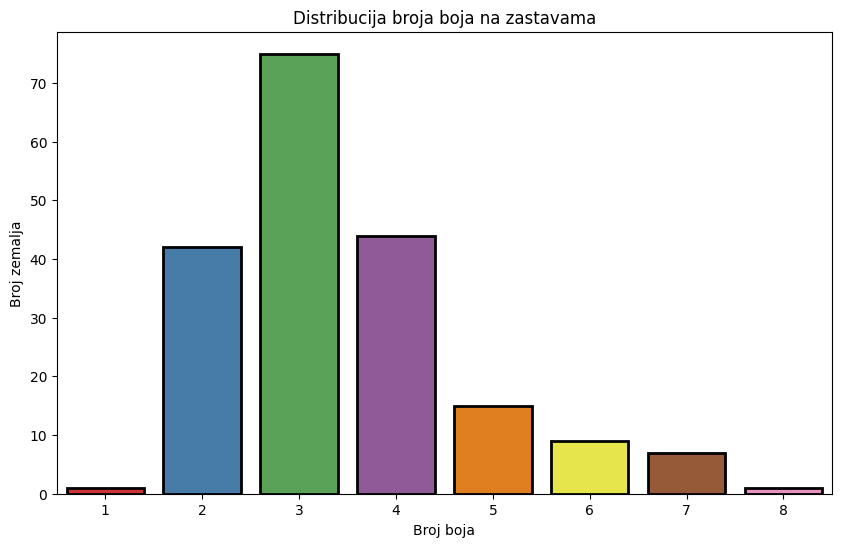

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='colours', edgecolor='black', linewidth=2, palette='Set1')
plt.title('Distribucija broja boja na zastavama')
plt.xlabel('Broj boja')
plt.ylabel('Broj zemalja')
plt.show()

Primetno je da najveći broj zastava ima tri boje na sebi, a najređe su zastave sa jednom i osam boja.

3. Prati se distribucija religija (religion) po broju zemalja, čime se završava prvi deo eksplorativne analize.

/tmp/ipython-input-166/3067525067.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='religion', edgecolor='black', linewidth=2, palette='Set1')


([<matplotlib.axis.XTick at 0x7e0bc4960bc0>,
 [Text(0, 0, 'Catholic'),
  Text(1, 0, 'Other Christian'),
  Text(2, 0, 'Muslim'),
  Text(3, 0, 'Buddhist'),
  Text(4, 0, 'Hindu'),
  Text(5, 0, 'Ethnic'),
  Text(6, 0, 'Marxist'),
  Text(7, 0, 'Others')])

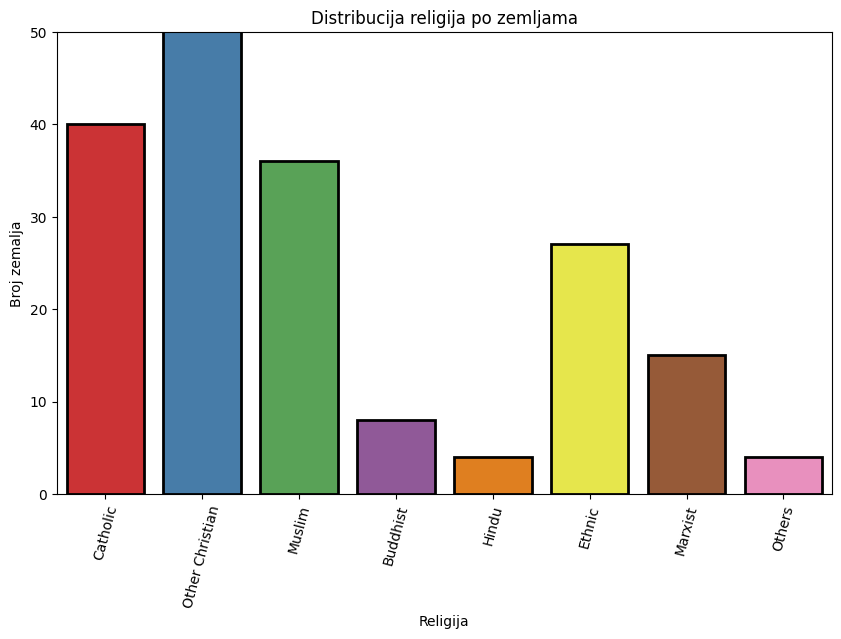

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='religion', edgecolor='black', linewidth=2, palette='Set1')
plt.title('Distribucija religija po zemljama')
plt.xlabel('Religija')
plt.ylabel('Broj zemalja')
plt.ylim(0, 50)
plt.xticks(ticks=[0, 1, 2, 3, 4, 5, 6, 7],
           labels=['Catholic', 'Other Christian', 'Muslim', 'Buddhist', 'Hindu', 'Ethnic', 'Marxist', 'Others'], rotation=75)

U ovoj podeli dominiraju hrišćanske zemlje koje su rezdeljene na ostale hrišćane i katolike zasebno, gde ostalih hrišćana ima najviše u odnosu na sve ostale grupe. Najmanji je broj zemalja gde je dominantna religija hinduizam ili neka druga religija.

*(Skup podataka je iz 1986. godine, te se stoga pojavljuju zemlje definisane kao markističke.)*

**Sada sledi drugi deo eksplorativne analize.**

U pitanju je poređenje atributa između klasa, gde je sa jedne strane uvek atribut religion.

Evo popisa atributa koji se prate, a za koje smo procenilio da su najznačajniji za procenu religije na osnovu elemenata na zastavi:
* bars = vertikalne pruge, koje religije imaju koliko zastava sa n brojem vertikalnih pruga
* stipes = horizontalne pruge
* colors = broj boja na zastavi
* circles = broj krugova na zastavi
* crosses = broj krstova na zastavi
* sunstars = broj sunaca i zvezdi na zastavi

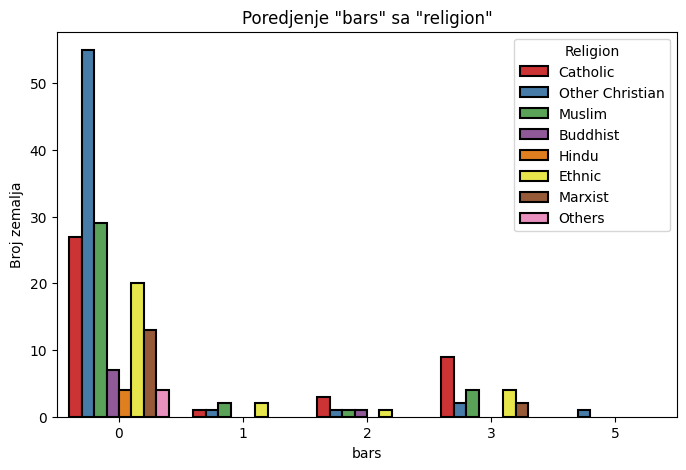

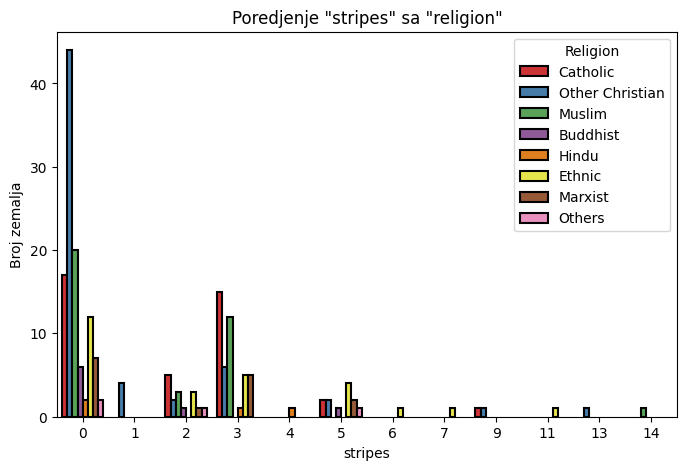

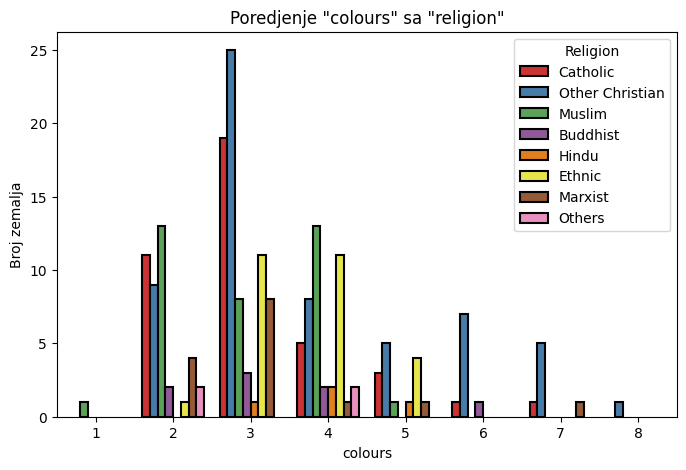

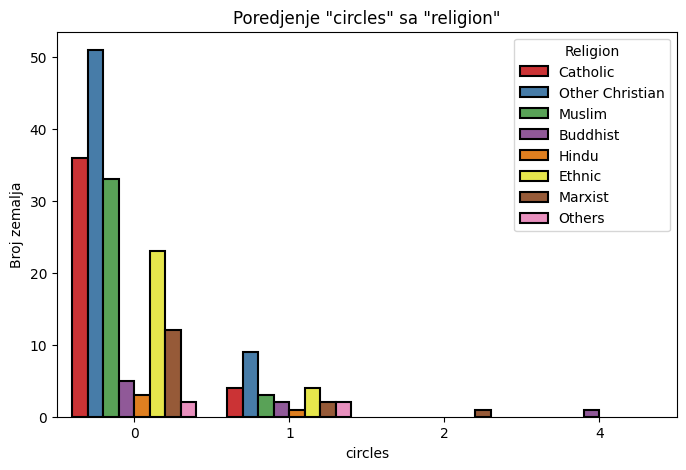

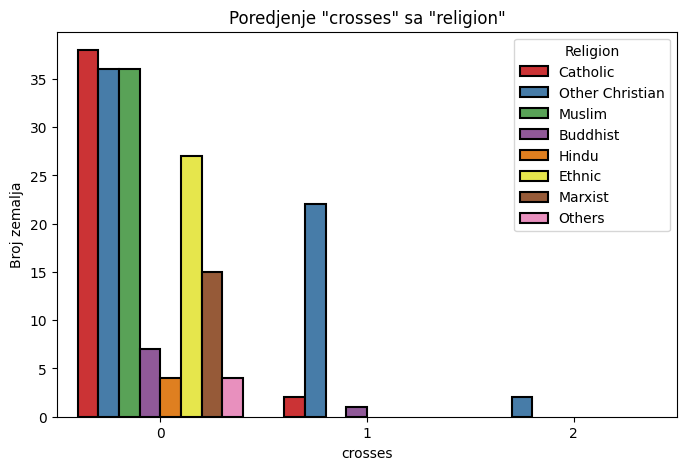

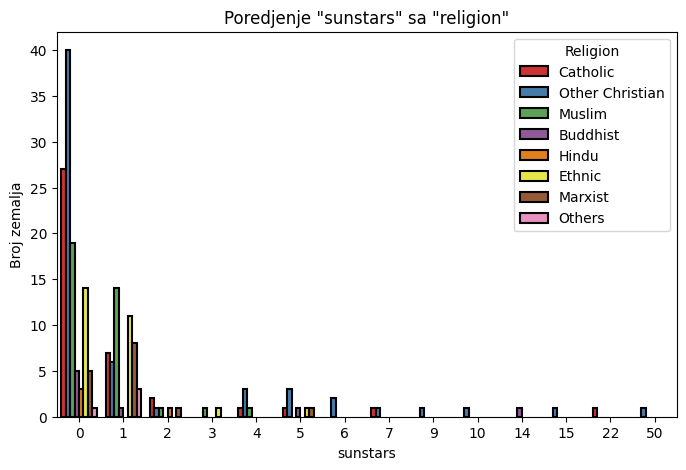

In [ ]:
# Definisanje legendi za religije
religion_labels = {
    0: 'Catholic', 1: 'Other Christian', 2: 'Muslim', 3: 'Buddhist', 4: 'Hindu', 5: 'Ethnic', 6: 'Marxist', 7: 'Others'
}

target_variable = 'religion'
compare_features = ['bars', 'stripes', 'colours', 'circles', 'crosses', 'sunstars']

for feature in compare_features:
    plt.figure(figsize=(8, 5))
    ax = sns.countplot(data=df, x=feature, hue=target_variable, edgecolor='black', linewidth=1.5, palette='Set1')

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, [religion_labels[int(label)] for label in labels], title='Religion', loc='upper right')

    plt.title(f'Poredjenje "{feature}" sa "{target_variable}"')
    plt.xlabel(feature)
    plt.ylabel('Broj zemalja')
    plt.show()

* **bars** - Na osnovu ovih rezultata, vidi se da najveći broj zastava koje pripadaju državama ostalih hrišćana nemaju nijednu vertikalnu prugu, a to važi i za muslimane i katolike u velikom broju. Primetan je rezultat u delu za tri vertikalne pruge, gde se ističu katoličke države.
* **stripes** - Na osnovu ovih rezultata, vidi se da je najveći broj država koje imaju nula horizontalnih pruga ponovo izražen na isti način kao i u primeru iznad. Dodatno, ako država ima tri horizontalne pruge, uglavnom će to biti katolička ili muslimanska država.
* **colours** - Na osnovu ovih rezultata, vidi se da je među svih hrišćanima najčešći model zastave koja ima tri boje, a kod muslimanskih država tu su ili zastave sa dve ili četiri boje najčešće. Istakle su se još i etničke religije koje uglavnom imaju ili tri ili četiri boje.
* **circles** - Na osnovu ovih rezultata, vidi se da ako zastava ima jedan krug, najveće su šanse da je u pitanju zastava države gde su ostali hrišćani, što je najznačajnija informacija sa ovog grafika
* **crosses** - Na osnovu ovih rezultata, vidi se da ako država ima jedan krst, gotovo sigurno je u pitanju zastava države ostalih hrišćana, a to mogu biti još i katolička ili budistička država. Ako je broj krstva dva, to su uvek ostali hrišćani.
* **sunstars** - Na osnovu ovih rezultata, vidi se da ako država ima na zastavi jednu zvezdu ili sunce, da je to uglavnom muslimanska država, mada u stopu ih prate države koje imaju etničke religije. Ako država nema ništa od ovoga na zastavi to najčešće ukazuje da je u pitanju neka od hrišćanskih zastava.

Sada se posmatraju kontinenti (landmass) i oblasti sveta podeljene u kvadrante na mapi (zone) prema dominantnim bojama, a potom i prema religijama.

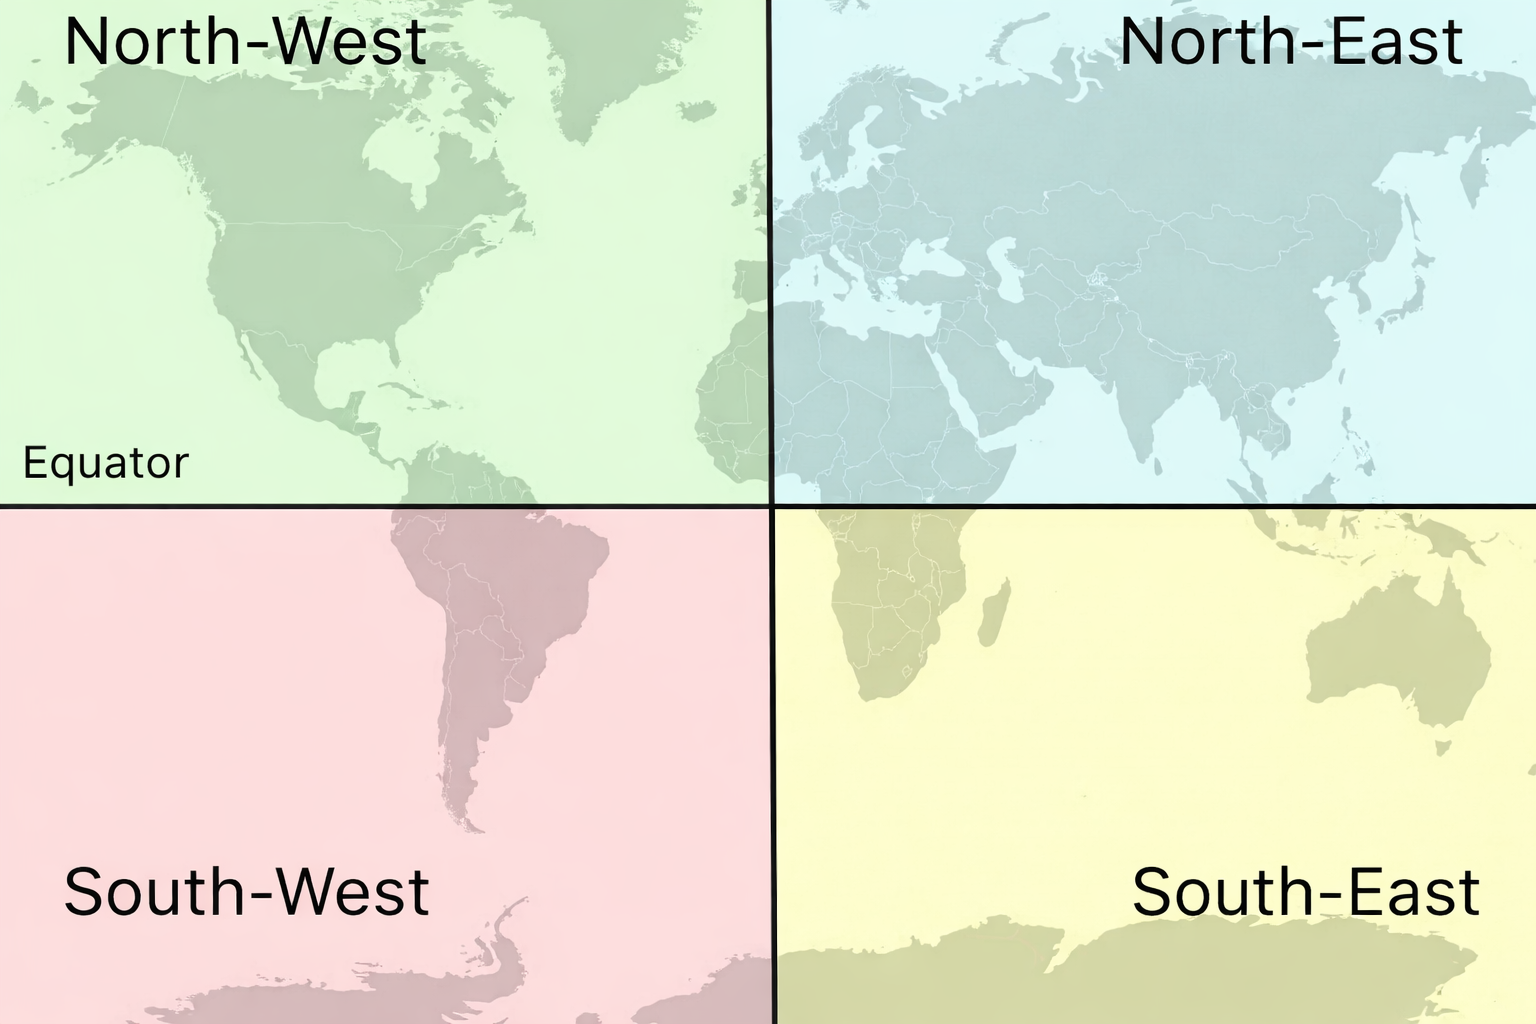

Iznad je priložena slika koja grafički opisuje geografsku podelu na kvadrante, zarad kasnijeg lakšeg tumačenja rezultata analize.

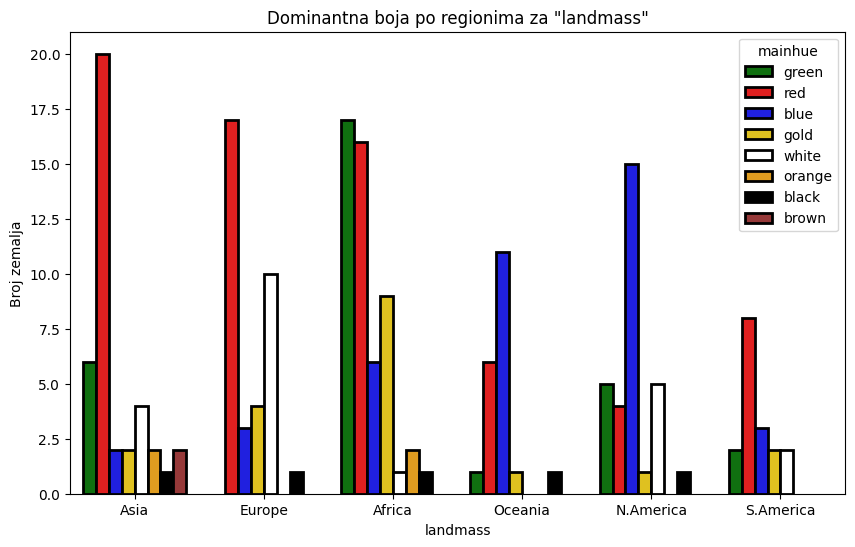

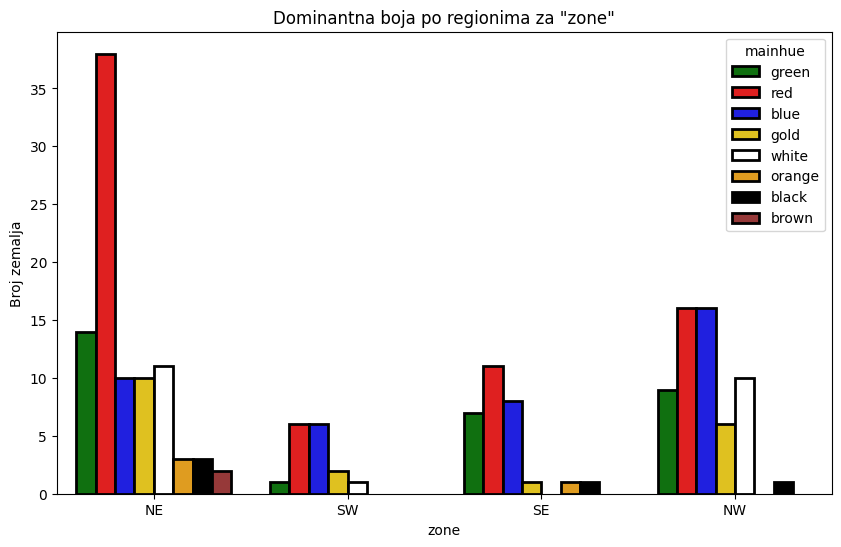

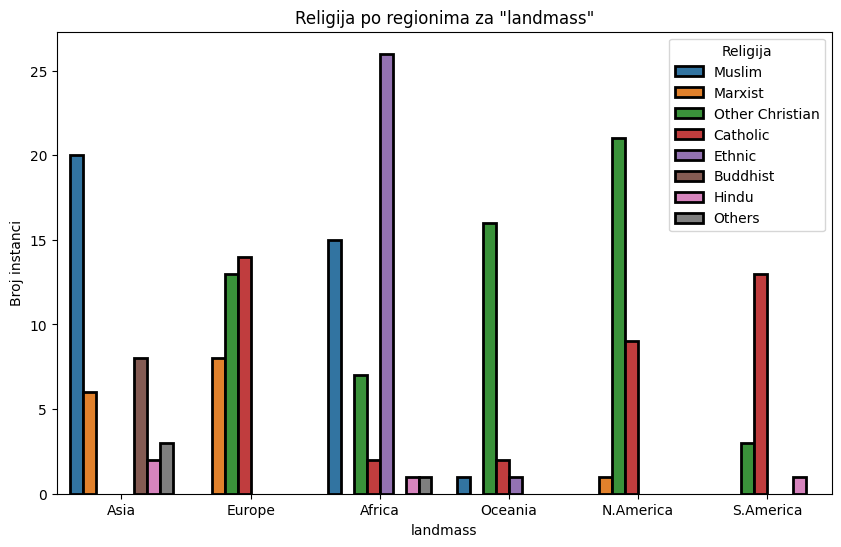

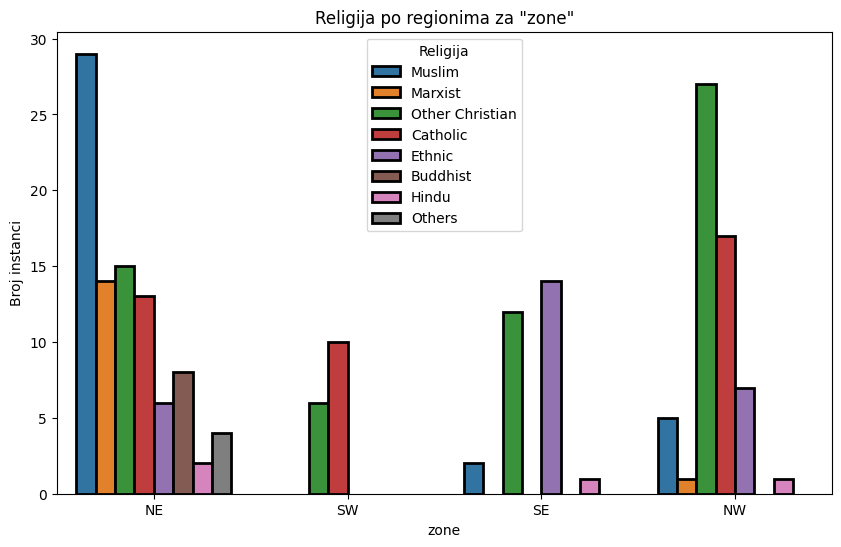

In [ ]:
df = pd.read_csv("flag.data", header=None, names=columns)

# Mapiranje za geografske karakteristike
landmass_map = {1:'N.America',2:'S.America',3:'Europe',4:'Africa',5:'Asia',6:'Oceania'}
zone_map = {1:'NE',2:'SE',3:'SW',4:'NW'}
religion_map = {
    0:'Catholic',1:'Other Christian',2:'Muslim',3:'Buddhist',
    4:'Hindu',5:'Ethnic',6:'Marxist',7:'Others'
}

# Zamena vrednosti u DataFrame-u
df['landmass'] = df['landmass'].map(landmass_map)
df['zone'] = df['zone'].map(zone_map)
df['religion'] = df['religion'].map(religion_map)

regional_features = ['landmass', 'zone']

# Deo po dominantnoj boji
for feature in regional_features:
    plt.figure(figsize=(10, 6))
    palette = {hue: hue for hue in df['mainhue'].unique()}

    sns.countplot(
        data=df,
        x=feature,
        hue='mainhue',
        palette=palette,
        edgecolor='black',
        linewidth=2
    )

    plt.title(f'Dominantna boja po regionima za "{feature}"')
    plt.xlabel(feature)
    plt.ylabel('Broj zemalja')
    plt.show()

#Deo po religiji
for feature in regional_features:
    plt.figure(figsize=(10, 6))

    sns.countplot(
        data=df,
        x=feature,
        hue='religion',
        edgecolor='black',
        linewidth=2
    )

    plt.title(f'Religija po regionima za "{feature}"')
    plt.xlabel(feature)
    plt.ylabel('Broj instanci')
    plt.legend(title='Religija')
    plt.show()

**Dominantna boja:**
* **landmass** - Crvena boja je prikazana kao najdominantnija boja u Aziji, Evropi i Južnoj Americi, a jak rezultat prisutan je i u Africi. Na prva tri pomenuta kontinenta crvena je daleko prisutnija od ostalih boja kao dominantna. U Africi malo veći stepen dominacije ima zelena boja. Plava boja je najjača u Severnoj Americi i Okeaniji. Dodatno, bela boja se dosta ističe u Evropi, a žuta u Africi.
* **zone** - U severo-istočnom kvadrantu potpuno dominira crvena boha, dok su u severozapadnom izjednačene plava i crvena. Ta izjednačenost važi i za jugo-zapadni kvadrant. U jugo-istočnom kvadrantu blagu prednost ima crvena boja, a prate je plava i zelena.

**Religija**
* **landmass** - U Aziji je najveći broj muslimanskih zemalja. U Evropi su prisutne samo tri relgije, najčešća je katoličanstvo, vrlo blisko je prati ostalo hrišćanstvo, a potom su prisutne i zemlje označene kao marksističke. U Africi je najprisutnija etnička religija, a po broju su se istale i muslimanske države. U Okeaniji i Severnoj Americi dominiraju ostalu hrišćani, dok je u slučaju Južne Amerike dominacija pripala katolicima.
* **zone** - U severo-istočnom kvadrantu najzastuljenije su muslimanske zemelje. U severo-zapadnom to su ostali hrišćani, a potom i katolici. U jugo-istočnom najviše su prisutne etničke religije i ostali hrišćani. Na kraju, u jugo-zapadnom kvadrantu, prisutni su samo ostali hrišćani i katolici kojih ima više.

Sledeći grafik će sublimirati ovaj deo u sagledavanju rasporeda dominantnih boja zastava u odnosu na religije.

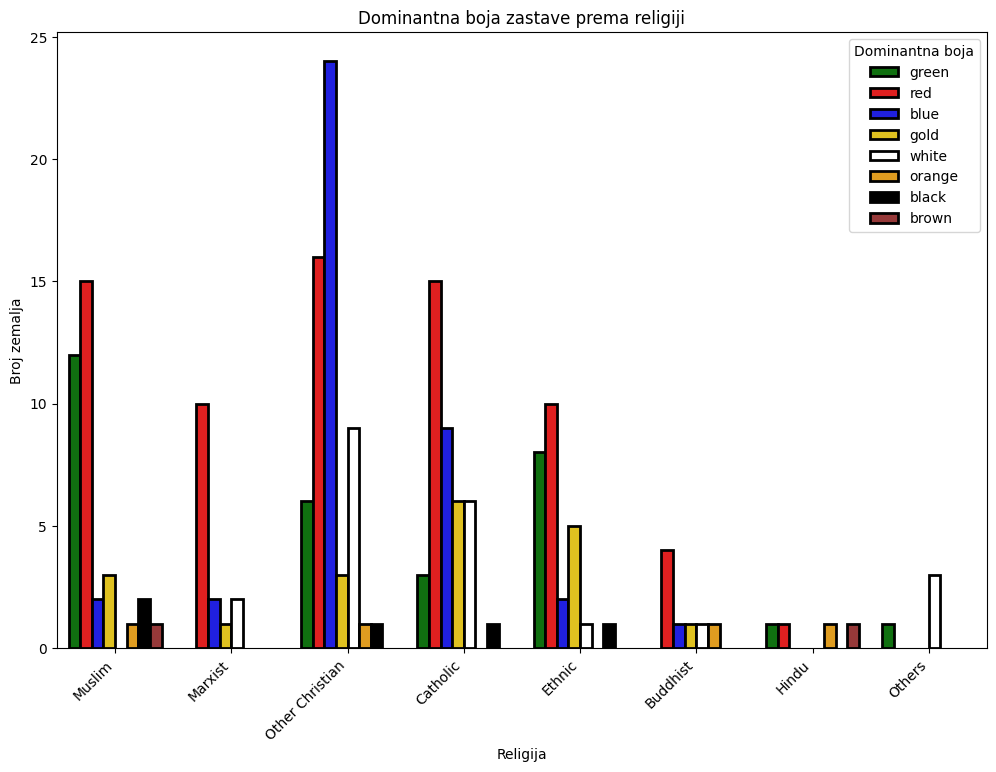

In [ ]:
df = pd.read_csv("flag.data", header=None, names=columns)

df['religion'] = df['religion'].map(religion_labels)

plt.figure(figsize=(12, 8))
sns.countplot(data=df, x='religion', hue='mainhue', palette=colors, edgecolor='black', linewidth=2)
plt.title('Dominantna boja zastave prema religiji')
plt.xlabel('Religija')
plt.ylabel('Broj zemalja')
plt.legend(title='Dominantna boja', loc='upper right')
plt.xticks(rotation=45, ha='right')
plt.show()

Primetno je da na zastavama muslimanskih država dominiraju crvena i zelena boju kao glavne boje, isti slučaj je i kod država čije su religije etničke. Kod marksističkih država najdominantnija je crvena boja, kao i kod budističkih. Kod ostalih Hrišćana, a i kod katolika u prve tri boje nalaze se crvena, plava i bela po stepenu dominantnosti. Kod ostalih država najviše se ističe bela boja, dok kod hinduističkih država nema jasne najdominantnije boje.

**Sada sledi treći i poslednji deo eksplorativne analize, korelaciona matrica:**

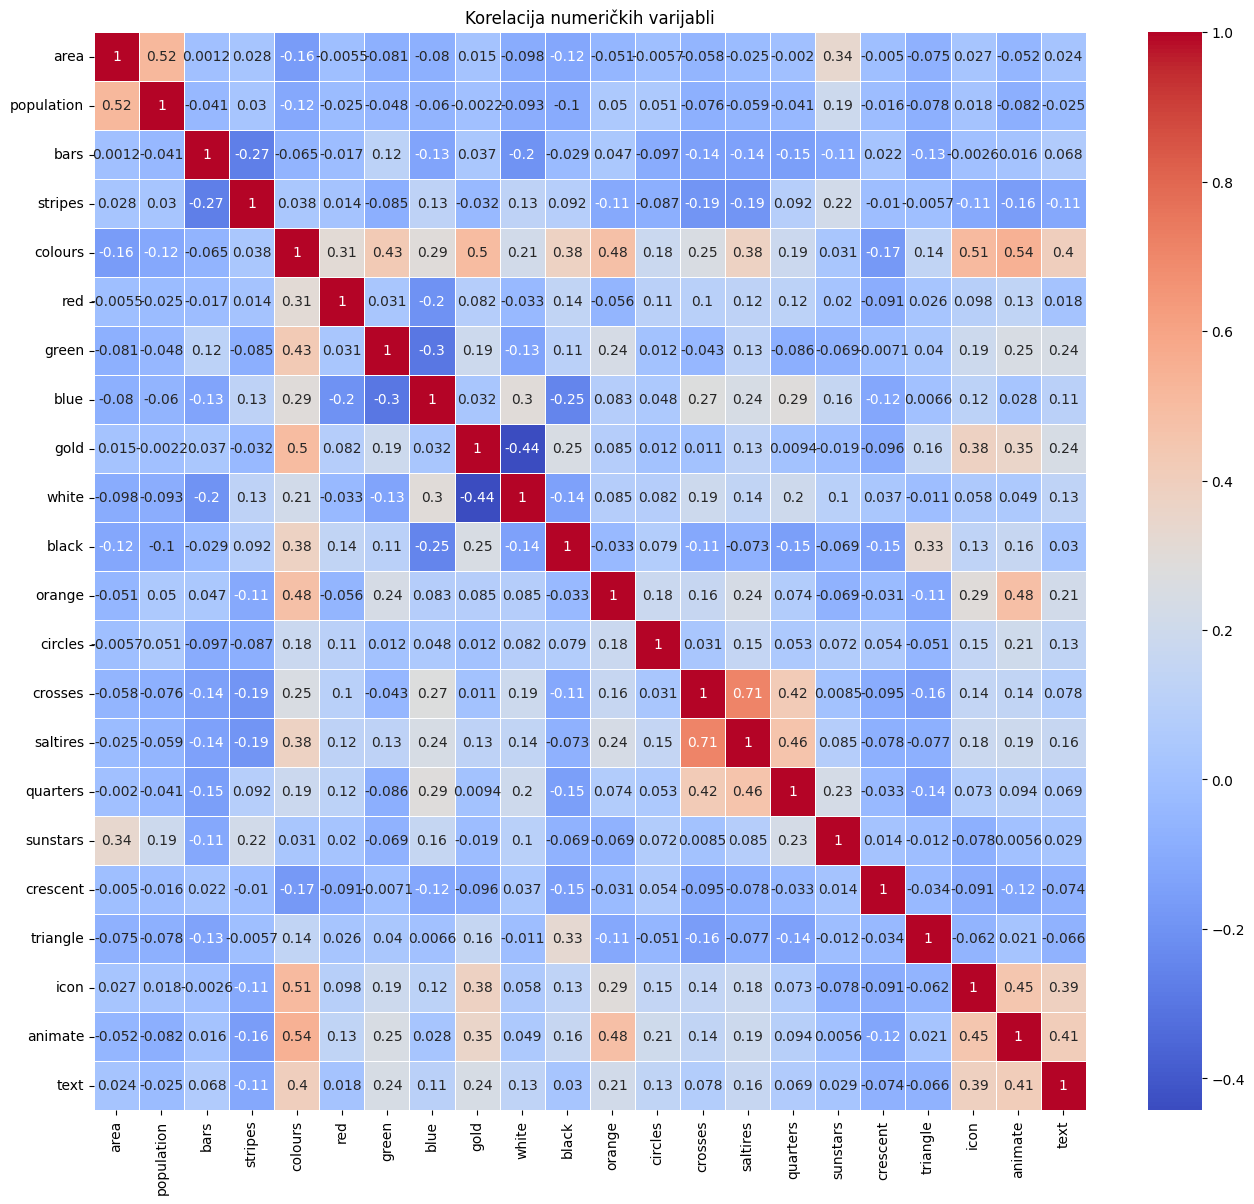

In [ ]:
numerical_features = ['area', 'population', 'bars', 'stripes', 'colours', 'red', 'green', 'blue', 'gold', 'white',
                      'black', 'orange', 'circles', 'crosses', 'saltires', 'quarters', 'sunstars', 'crescent',
                      'triangle', 'icon', 'animate', 'text']

plt.figure(figsize=(16, 14))
sns.heatmap(df[numerical_features].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Korelacija numeričkih varijabli')
plt.show()

Ova matrica daje uvid u odnose izreženih atributa, a ovo su zaključci:
* area i population -> veće zemlje imaju veće populacije
* area i sunstars -> veća površina imaće više zvezdi i sunaca na zastavi
* bars i stripes -> ima jednih, neće biti drugih
* bars i white -> vertikalne pruge i bela boja se ne dešavaju zajedno
* colors i red/green/gold/orange/icon/animate/text -> više boja, pa pojaviće se i crvena/zelena/žuta/narandžasta/sličica/tekst
* green i blue -> isključuju jedna drugu
* blue i white -> oćekuju jedna drugu
* blue i black -> isključuju jedna drugu
* gold i animte/icon -> očekuju jedni druge
* gold i white -> isključuju se
* crosses i saltiers -> očekuju se (objašnjenje atributa saltiers: saltiers je oznaka za postojanje Andrejinog krsta na zastavi, on izgleda kao ćirilično slovo h, glavni primer može biti zastava Škotske)

## **Random Forest - Ilija**

Klasifikator Random Forest se bazira na konceptu ansambla stabala
odluke, gde se kombinuje veliki broj stabala treniranih na
različitim podskupovima podataka. Konačna klasifikacija
se dobija većinskom odlukom svih stabala.

**Biblioteke potrebne u delu koji se koristi za Random Forest**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

import shap

**Učitavanje fajla**

In [ ]:
print("Uploadujte fajl 'flag.data'")
uploaded = files.upload()

columns = [
    "name","landmass","zone","area","population","language","religion","bars","stripes","colours",
    "red","green","blue","gold","white","black","orange","mainhue","circles","crosses",
    "saltires","quarters","sunstars","crescent","triangle","icon","animate","text","topleft","botright"
]

df = pd.read_csv("flag.data", header=None, names=columns)

Uploadujte fajl 'flag.data'


Saving flag.data to flag.data


**Definisanje target kolone i one-hot encoding za kategoričke atribute**


In [ ]:
target_col = "religion"

X = df.drop(columns=[target_col, "name"])
y = df[target_col]

# One-hot za kategoričke kolone
X = pd.get_dummies(X, columns=["mainhue", "topleft", "botright"])

Zašto one-hot encoding? Jer modeli mašinskog učenja ne mogu da rade direktno sa tekstualnim podacima. Stoga, nakon primene ovog postupka na primeru mainhue postojaće kolone mainhue_red, mainhue_blue i tako dalje u kojima će 0 i 1 označavati da li je ta boja prisutna kao dominantna na određenoj zastavi ili ne.

**Podela na trening i test skup podataka**


In [ ]:
TEST_SIZE = 0.15
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

Početak rada sa ovim modelom zahtevao je najpre da se
ceo skup podataka podeljen na trening skup (85%) i test
skup (15%). Podela je stratifikovana da bi se očuvao
odnos pojavljivanja religija u trening i test skupu.

**Random Forest i Grid Search**

In [ ]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Najbolji hiperparametri:", grid.best_params_)
print("Najbolji prosečni F1 (CV):", grid.best_score_)


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Najbolji hiperparametri: {'max_depth': 5, 'n_estimators': 100}
Najbolji prosečni F1 (CV): 0.5097613754126359


Na trening skupu izvršena je
pretraga najboljih hiperparametara pomoću unakrsne
validacije sa pet particija. U svakoj iteraciji unakrsne
validacije četiri particije su korišćene za treniranje, dok je
peta služila za validaciju, i taj postupak je ponavljan dok
svaka particija nije jednom iskorišćena za validaciju. Na
osnovu postignutih rezultata izabrani su optimalni
hiperparametri, nakon čega je model ponovo treniran na
celom trening skupu.

Korišćeni parametri:
* Broj različitih stabala koja će postojati u
ansamblu za treniranje zarad donošenja odluke. Korišćene
vrednosti su: 50, 100 i 200.
* Maksimalna dubina stabla, kojom se
kontroliše koliko daleko se stablo razvija. Dodeljene
vrednosti su: 5, 10 i None (nema ograničenja).

Ukratko ove vrednosti će
omogućiti da se pronađe balans između stabilnosti modela
(više
stabala) i kompleksnosti pojedinačnog stabla
(kontrola dubine).

**Graf poređenja: prosečna F1 po n_estimators**

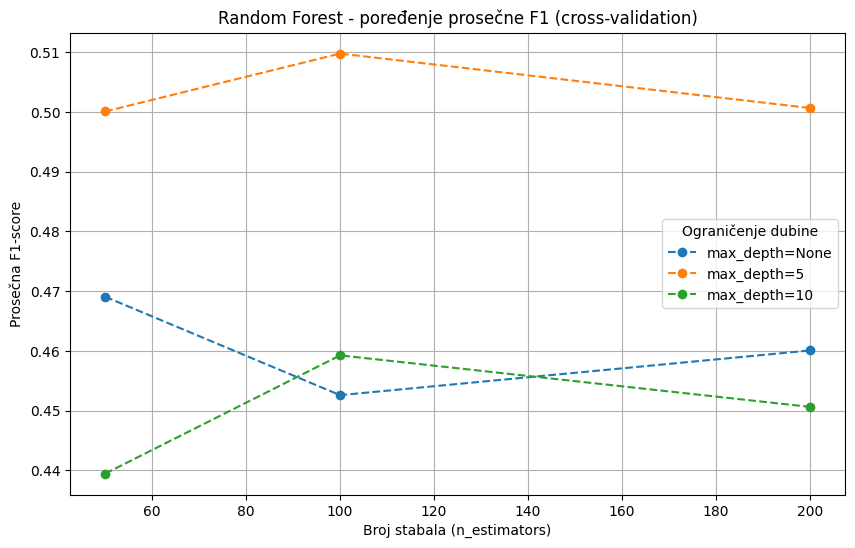

In [ ]:
results = pd.DataFrame(grid.cv_results_)

plt.figure(figsize=(10, 6))
for depth in param_grid['max_depth']:
    if depth is None:
        subset = results[results['param_max_depth'].isna()]
        depth_label = "None"
    else:
        subset = results[results['param_max_depth'] == depth]
        depth_label = str(depth)
    plt.plot(
        subset['param_n_estimators'],
        subset['mean_test_score'],
        marker='o',
        linestyle='dashed',
        label=f'max_depth={depth_label}'
    )
plt.title('Random Forest - poređenje prosečne F1 (cross-validation)')
plt.xlabel('Broj stabala (n_estimators)')
plt.ylabel('Prosečna F1-score')
plt.legend(title="Ograničenje dubine")
plt.grid(True)
plt.show()

Upoređena je f1 mera na trening skupu u
zavisnosti od kriterijuma koji biramo, maksimalne dubine
stabla i broj različitih stabala koja će postojati u ansamblu
za treniranje.

Iz priloženog se vidi da je najbolja kombinacija parametara maksimalna dubina 5 i broj stabala 100, gde f1 mera iznosi približno 0,51. Primetno je da je generalno najbolje birati ograničenje dubine koje je jednako 5.

**Evaluacija na test skupu**

In [ ]:
best_rf = grid.best_estimator_
y_pred = best_rf.predict(X_test)

f_score = f1_score(y_test, y_pred, average='macro')
print("F1 score:", f_score)

F1 score: 0.40208333333333335


Konačna tačnost na podacima izdvojenim na početku
za testiranje je oko 0,4.

**Matrica konfuzije (test skup)**

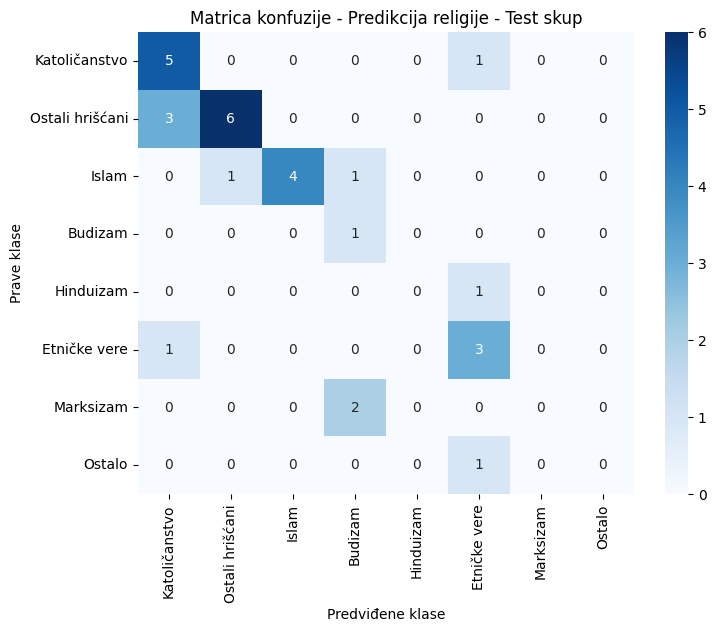

In [ ]:
# Mape za religije
religion_labels = ["Katoličanstvo", "Ostali hrišćani", "Islam", "Budizam", "Hinduizam", "Etničke vere", "Marksizam", "Ostalo"]

# Matrica konfuzije
conf_mat = confusion_matrix(y_test, y_pred)

# Heatmap matrice konfuzije
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=religion_labels,
            yticklabels=religion_labels)
plt.title("Matrica konfuzije - Predikcija religije - Test skup")
plt.xlabel("Predviđene klase")
plt.ylabel("Prave klase")
plt.show()

Na matrici konfuzije koja prikazuje performans nad test skupom vidljivo je sledeće:
* katoličanstvo - uglavom pogađano bez problema
* ostali hrišćani - skoro uglavnom pogađano, ali postoji mešanje sa katoličanstvon
* islam - uglavom pogađano bez problema
* budizam - pogođen
* hinduizam - promašen, zamenjen entičkim verama
* etničke vere - uglavom pogađano bez problema
* marksizam - pogođeno
* ostale vere - promašeno, zamenjeno etničkim verama

**SHAP analiza**

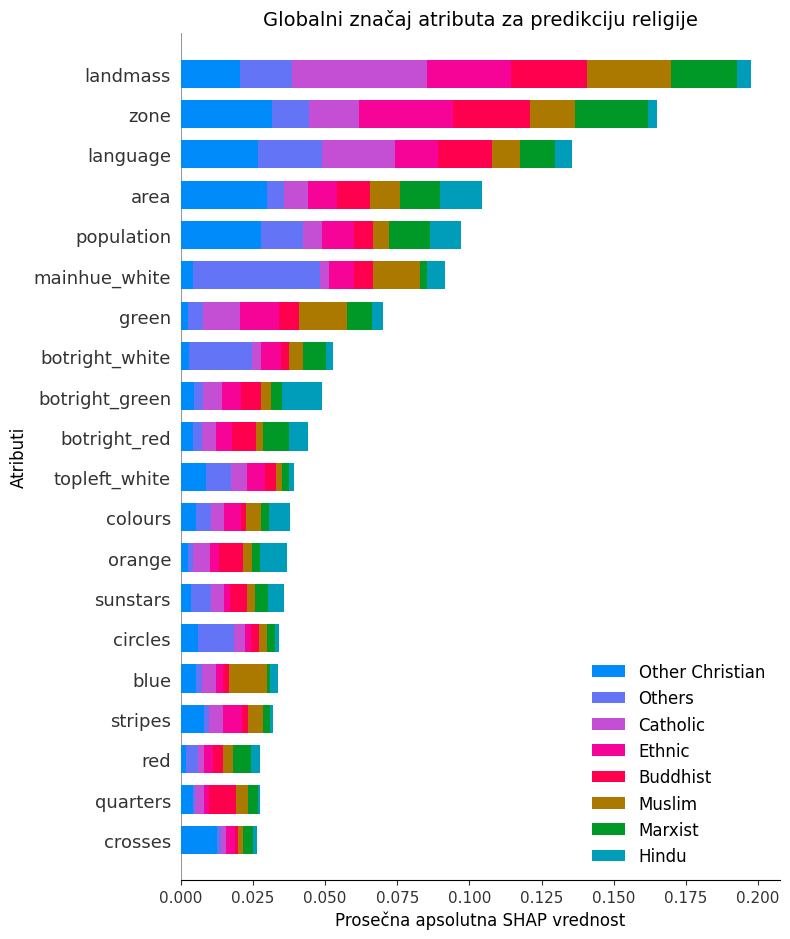

In [ ]:
religion_labels = { 0: 'Catholic', 1: 'Other Christian', 2: 'Muslim', 3: 'Buddhist', 4: 'Hindu', 5: 'Ethnic', 6: 'Marxist', 7: 'Others' }

#Explainer za Random Forest
explainer = shap.TreeExplainer(best_rf) #računa doprinos feature-a kroz sve grane stabla
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(12, 6))
class_names = list(religion_labels.values())
shap.summary_plot(shap_values, X_test, plot_type="bar", feature_names=X_test.columns, class_names=class_names, show=False)
plt.title("Globalni značaj atributa za predikciju religije", fontsize=14)
plt.xlabel("Prosečna apsolutna SHAP vrednost", fontsize=12)
plt.ylabel("Atributi", fontsize=12)
plt.tight_layout()
plt.show()

SHAP je metoda za objašnjavanje predikcija modela. Na grafiku se vidi koliko je feature u proseku jak u donošenju odluka (bez obzira na smer, bio on negativan ili pozitivan).

Grafik prikazuje da su za određivanje religije najbitniji atributi poput kontinenta, geografskog kvadranta, jezika, površine, populacije i dominacije bele boje na zastavi. Različitim bojama prikazano je koliko je u okviru određene religije u nekom atributu bilo značaja za predviđanje iste. Tako na primer, ako je dominantna boja bela, to je najviše pomagalo da se prepoznaju ostale religije.

## **Support Vector Machine - Nikola**

Na osnovu drugog rada iz predloga projekta, koristićemo SVM - Support Vectore Machines model za predikciju religije koristeći opisani skup podataka. SVM je model nadgledanog mašinskog učenja pogodan za rešavanje klasifikacionih problema. Ukratko, ideja SVM je da pronalazi maksimalnu marginu između podataka koju su linearno separabilni. Iako je SVM linearni klasifikator moguće ga je koristiti i za podatke koji nisu linearno separabilni tako što se ulazni podaci mapiraju na višedimenzioni prostor gde ih je moguće linearno razdvajati.

**Importovanje potrebnih biblioteka za predikciju pomoću SVM**

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import shap

from google.colab import files
from sklearn.metrics import confusion_matrix, classification_report, precision_score, accuracy_score, recall_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

**Učitavanje skupa podataka**

In [ ]:
print("Učitajte fajl 'flag.data'")
uploaded = files.upload()

columns = ["name", "landmass", "zone", "area", "population", "language", "religion", "bars",
           "stripes", "colours", "red", "green", "blue", "gold", "white", "black", "orange",
           "mainhue", "circles", "crosses", "saltires", "quarters", "sunstars", "crescent",
           "triangle", "icon", "animate", "text", "topleft", "botright"]

df = pd.read_csv("flag.data",
                 header=None,
                 names=columns)


Učitajte fajl 'flag.data'


Saving flag.data to flag (1).data


**Pretprocesiranje skupa podataka**

In [ ]:
target_col = "religion"

X = df.drop(columns=[target_col, "name"])
y = df[target_col]

X = pd.get_dummies(X, columns=["mainhue", "topleft", "botright"])

**Podela na trening i test skup**

Delimo skup podataka u trening i test skup u odnosu 85-15. Zbog nebalansiranosti klasa pravimo stratifikovanu podelu.

In [ ]:
RANDOM_STATE = 42

x_train, x_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.15,
                                                    stratify=y,
                                                    random_state=RANDOM_STATE)

**Definisanje parametara modela**

Koristi se SVC sa linear kernelom. Zbog nebalansiranosti klasa koristi se One-to-one pristup koji pravi binarni klasifikator za sve moguće parove klasa, i dodaje atribut class_weight u kome se podešava vrednost na "balanced" kako bi retke klase dobile veću težinu.
Takođe radi se 5-fold unakrsna validacija zbog male veličine skupa podataka.
Hiperparametar koji se podešava je parametar regularizacije C, da bismo našli najbolju marginu greške - uzimaju se vrednosti na logaritamskoj skali.

In [ ]:
clf_svm = make_pipeline(
    #StandardScaler() izbaceno zbog losijeg rezultata
    SVC(kernel="linear",
              random_state=RANDOM_STATE,
              decision_function_shape="ovo",
              class_weight="balanced")
)

grid = GridSearchCV(
    clf_svm,
    param_grid= {
        "svc__C": [0.01, 0.1, 1, 10, 100],
        },
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

**Obučavanje modela**

In [ ]:
grid.fit(x_train, y_train)

print("Najbolji hiperparametri:" + str(grid.best_params_))
print("Najbolji F1", grid.best_score_)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Najbolji hiperparametri:{'svc__C': 10}
Najbolji F1 0.3880418339584638


**Analiza najbolje vrednosti parametra C**

Analiziranjem dobijenog prosečnog f1 score-a (dobijenog uprosečavanjem rezultata unakrsne validacije) vidi se da je vrednost 10 za C dala najbolje rezultate, a i vrednost od 0.01 joj je blizu. Najbolja vrednost parametra nešto manja od 10 je očekivana jer ona predstavlja balans između slabe i jake regularizacije. Mala vrednost od 0.01 kao drugi najbolji rezultat verovatno je posledica malog skupa podataka i nedovoljno dobre obučenosti modela.

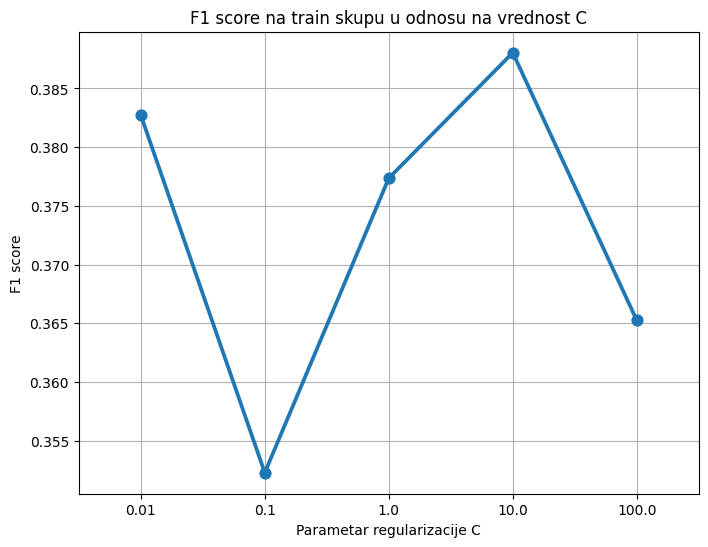

In [ ]:
results = pd.DataFrame(grid.cv_results_)

plt.figure(figsize=(8, 6))
sns.pointplot(x = results['param_svc__C'], y = results['mean_test_score'])
plt.title('F1 score na train skupu u odnosu na vrednost C')
plt.xlabel('Parametar regularizacije C')
plt.ylabel('F1 score')
plt.grid(True)
plt.show()

**Evaluacija obučenog modela na test skupu**

In [ ]:
best_model = grid.best_estimator_
y_pred = best_model.predict(x_test)

f1_score = f1_score(y_test, y_pred, average="macro")
print("F1 score: ", f1_score)

F1 score:  0.24826388888888887


**Matrica konfuzije**

Radi boljeg pregleda rezultata klasifikacije prikazana je matrica konfuzije.

Matrica pokazuje da su najbolje pogađani ostali hrišćani. Katoličanstvo vuče najviše lažno pozitivnih rezultata, a Islam najviše lažno negativnih. Religije sa malim brojem primeraka u test skupu su uglavnom klasifikovane kao hrišćanstvo, osim etničkih religija od kojih je polovina dobro pogođena.

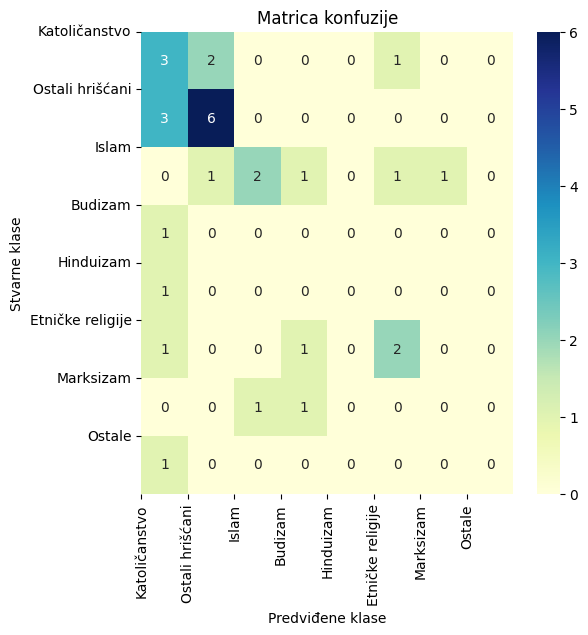

In [ ]:
conf_mat = confusion_matrix(y_test, y_pred)
religions = ["Katoličanstvo", "Ostali hrišćani", "Islam", "Budizam", "Hinduizam", "Etničke religije", "Marksizam", "Ostale"]
plt.figure(figsize=[6, 6])
sns.heatmap(conf_mat,
            annot=True,
            fmt="d",
            cmap="YlGnBu",
            )
plt.title("Matrica konfuzije")
plt.xlabel("Predviđene klase")
plt.ylabel("Stvarne klase")
plt.xticks(ticks=[0,1,2,3,4,5,6,7], labels=religions, rotation=90)
plt.yticks(ticks=[0,1,2,3,4,5,6,7], labels=religions, rotation=0)
plt.show()

**SHAP analiza feature-a**

Pomoću SHAP vrednosti može se videti koji feature-i najviše utiču na konfuziju između klasa kod kojih postoji najviše grešaka. Proverava se uticaj feature na razlikovanje katoličanstva i ostalih religija kod koga je bilo najviše lažno pozitivnih pogodaka i islama i ostalih religija kod koga je bilo najviše lažno negativnih.

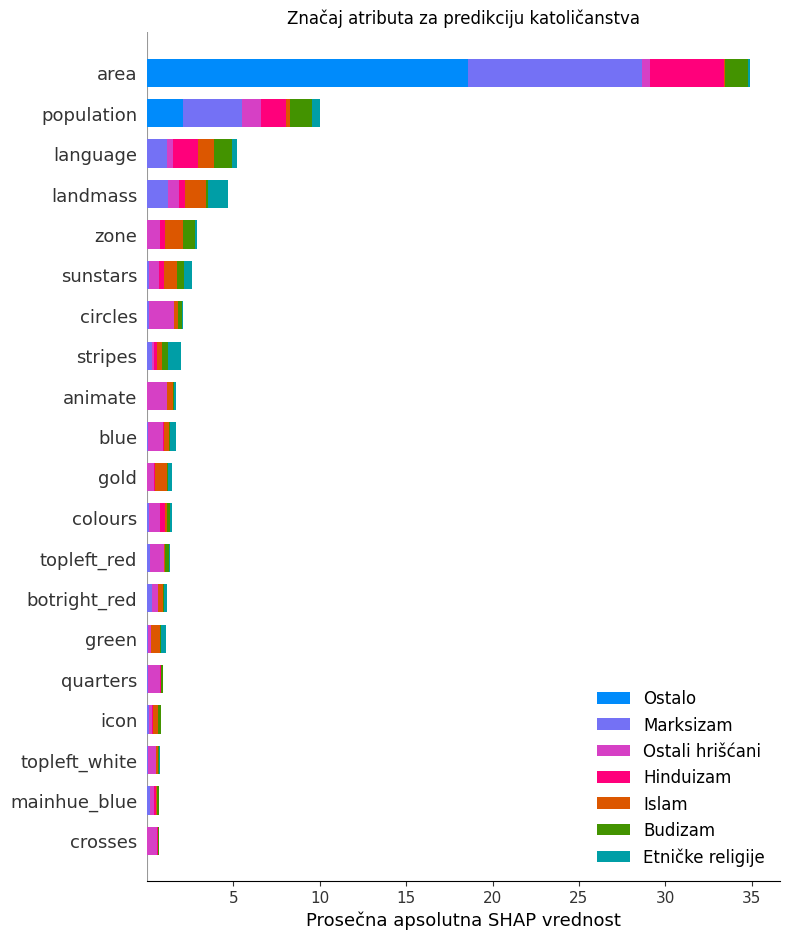

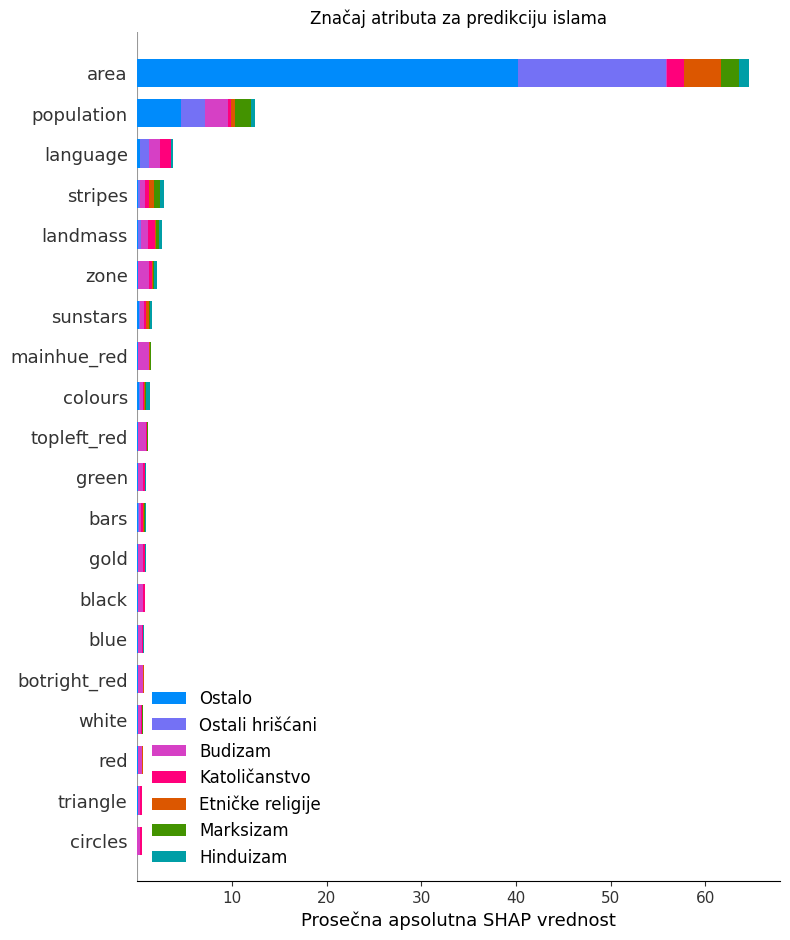

In [ ]:
explainer = shap.LinearExplainer(best_model[0], x_train)
shap_values = explainer.shap_values(x_test)

shap_values_catholic = shap_values[:,:,::4]

plt.figure(figsize=(4, 4))
plt.title("Značaj atributa za predikciju katoličanstva")
class_names = ['Ostali hrišćani', 'Islam', 'Budizam', 'Hinduizam', 'Etničke religije', 'Marksizam', 'Ostalo']

shap.summary_plot(shap_values_catholic, x_test, plot_type="bar", feature_names=x_test.columns, class_names=class_names, show=False)
plt.xlabel("Prosečna apsolutna SHAP vrednost")
plt.show()

shap_values_islam = shap_values[:,:,2::4]
plt.figure(figsize=(4, 4))
plt.title("Značaj atributa za predikciju islama")
class_names = ['Katoličanstvo', 'Ostali hrišćani', 'Budizam', 'Hinduizam', 'Etničke religije', 'Marksizam', 'Ostalo']

shap.summary_plot(shap_values_islam, x_test, plot_type="bar", feature_names=x_test.columns, class_names=class_names, show=False)
plt.xlabel("Prosečna apsolutna SHAP vrednost")
plt.show()
